In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\diabetes.csv")
df=data.copy()

In [3]:
df.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [9]:
q1=df["Insulin"].quantile(0.25)
q3=df["Insulin"].quantile(0.75)
IQR=q3-q1
min=q1-(1.5*IQR)
max=q3+(1.5*IQR)

In [10]:
df=df[(df["Insulin"]>min)&(df["Insulin"]<max)]

In [11]:
q1=df["DiabetesPedigreeFunction"].quantile(0.25)
q3=df["DiabetesPedigreeFunction"].quantile(0.75)
IQR=q3-q1
min=q1-(1.5*IQR)
max=q3+(1.5*IQR)

In [12]:
df=df[(df["DiabetesPedigreeFunction"]>min)&(df["DiabetesPedigreeFunction"]<max)]

In [13]:
data.shape,df.shape

((768, 9), (703, 9))

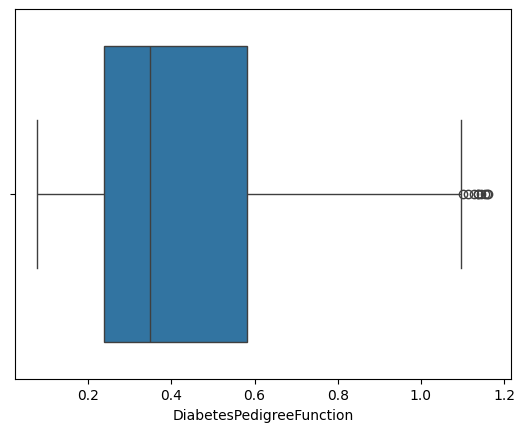

In [14]:
sns.boxplot(x="DiabetesPedigreeFunction",data=df)
plt.show()

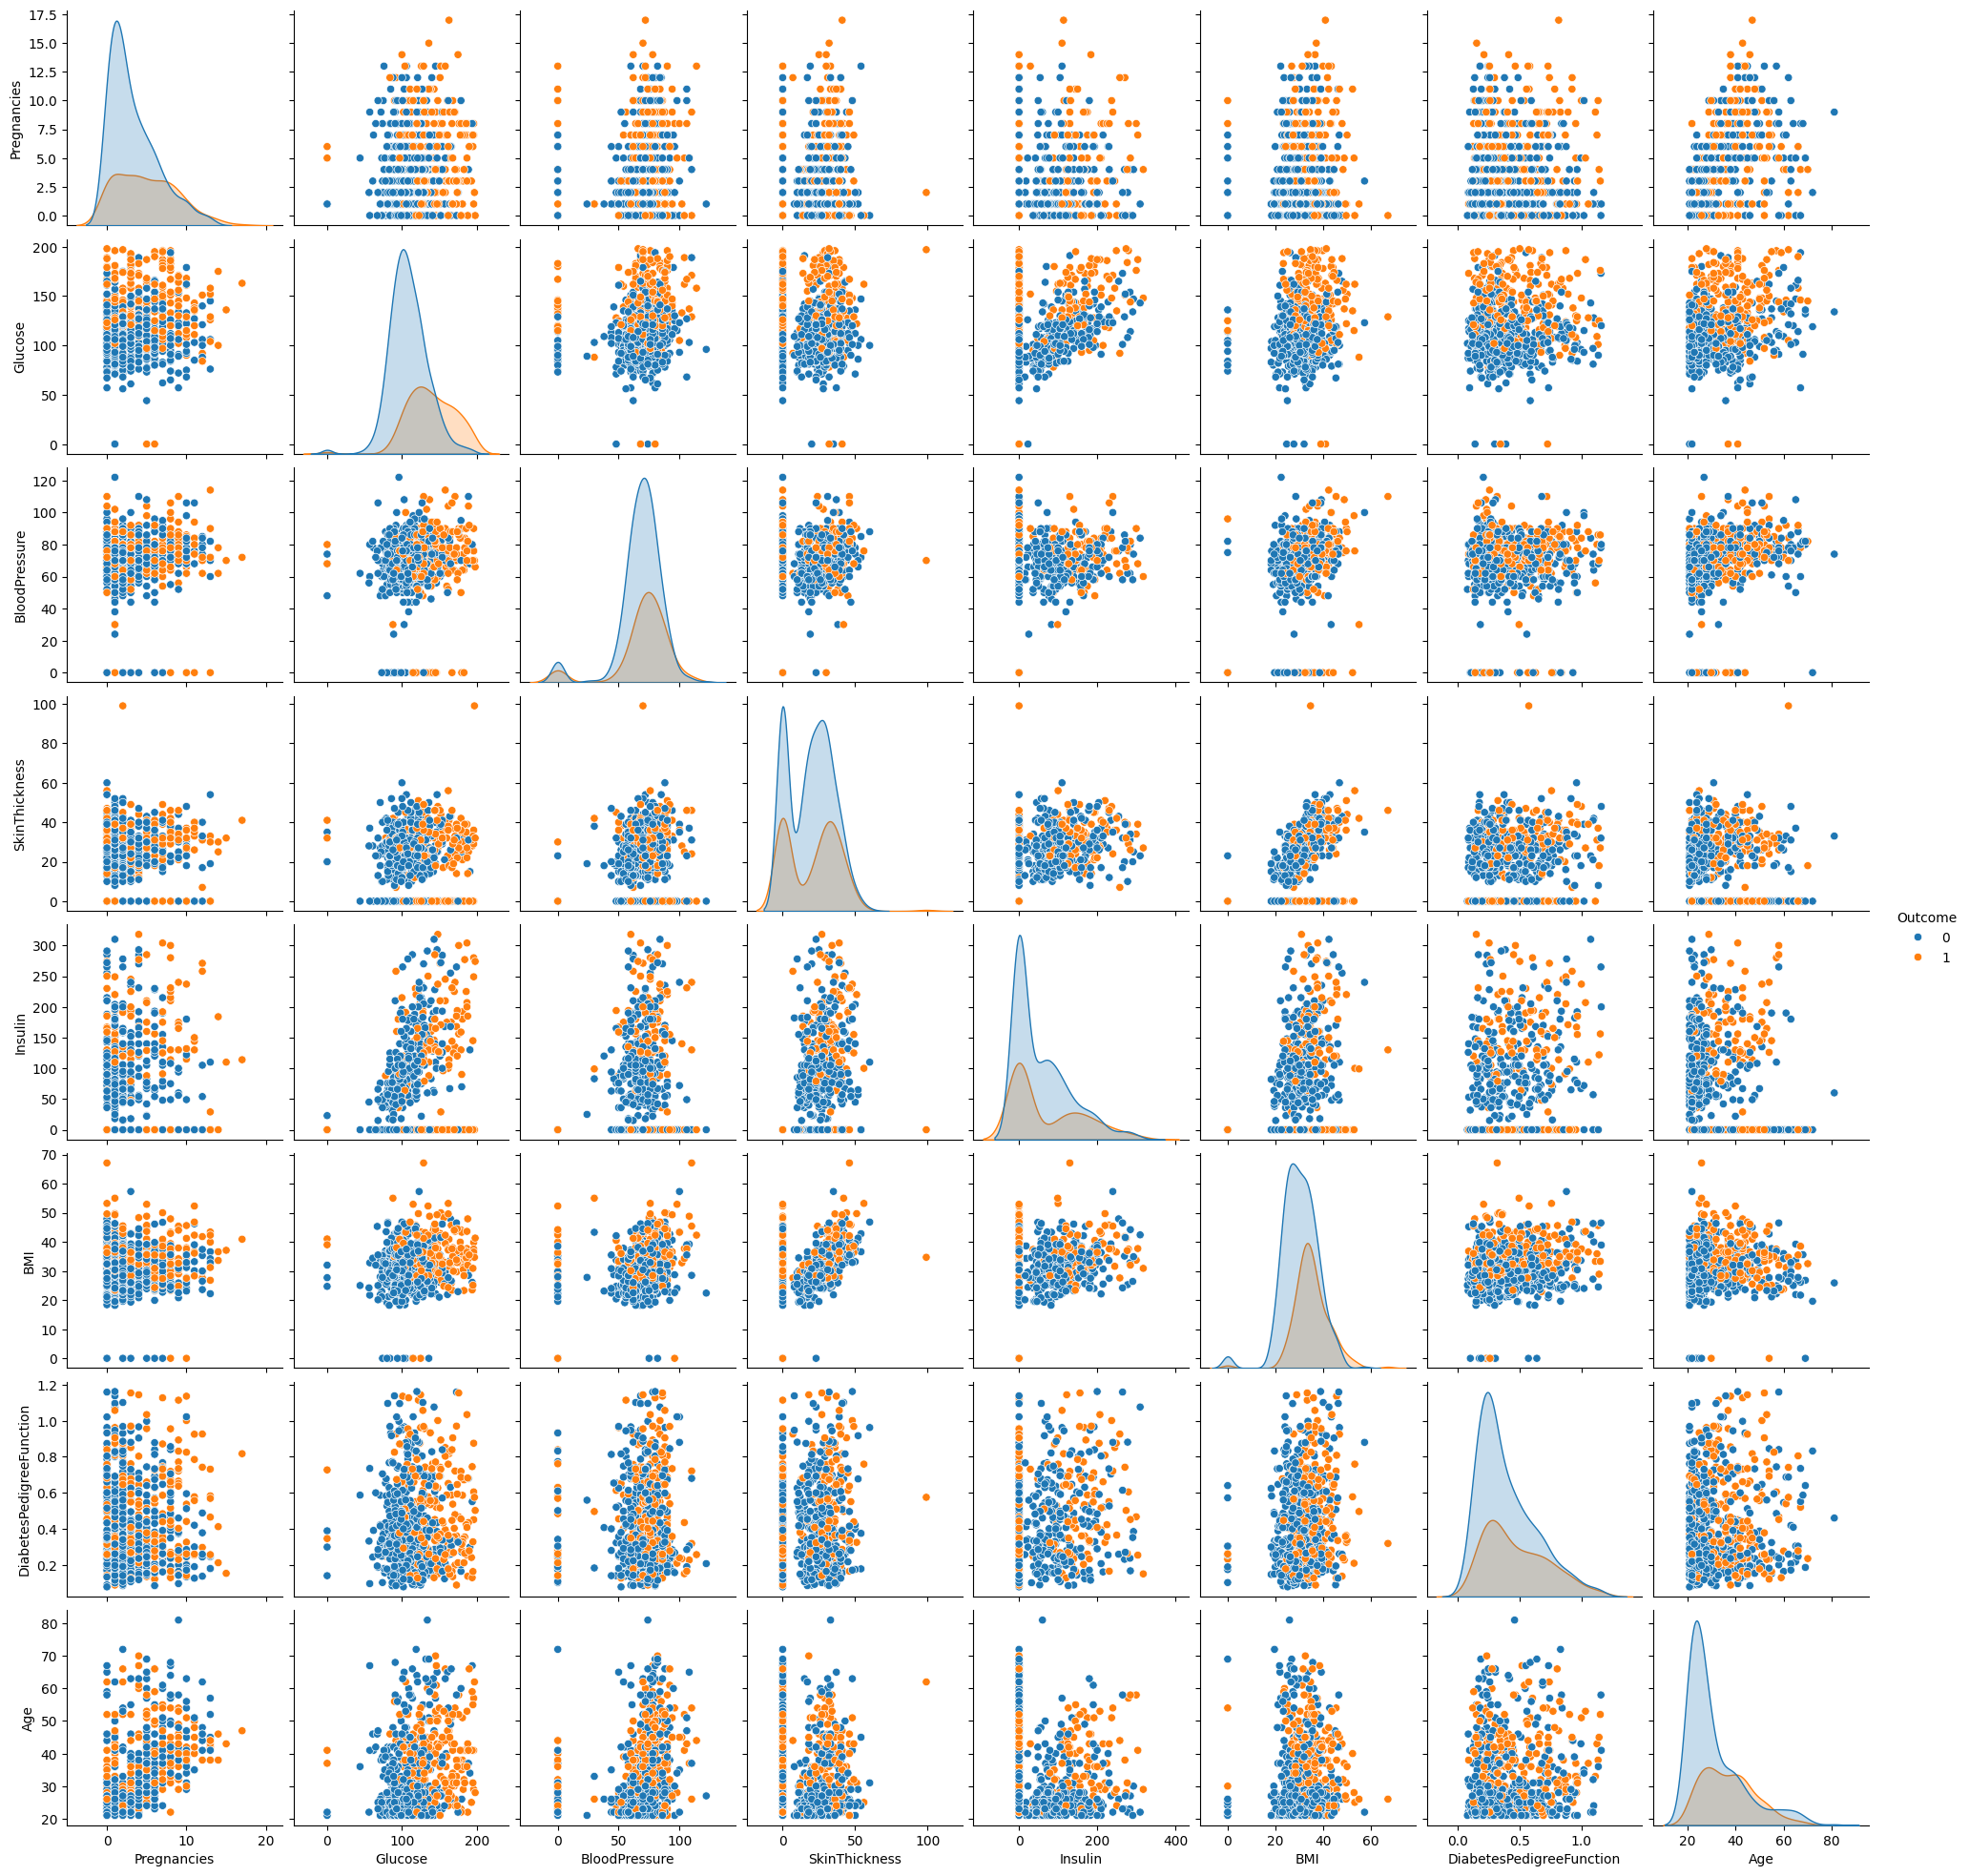

In [15]:
sns.pairplot(data=df,hue="Outcome")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [17]:
X=df[["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]]
Y=df["Outcome"] 

In [18]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [19]:
X=sc.transform(X)

In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [21]:
lg=LogisticRegression()
lg.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,lg.predict(X_test))

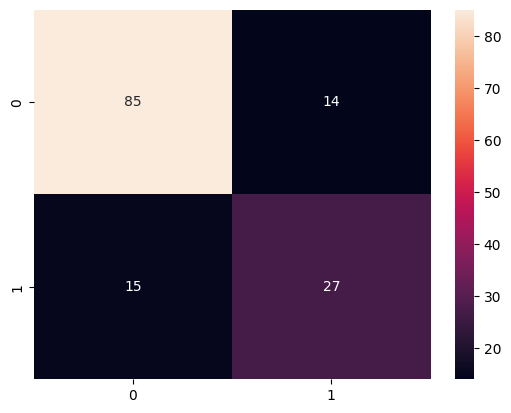

In [23]:
sns.heatmap(cm,annot=True)
plt.show()

In [24]:
#cm2=confusion_matrix(Y_test,knn.predict(X_test))
#sns.heatmap(cm2,annot=True)
#plt.show()

In [25]:
lg.score(X_test,Y_test),lg.score(X_train,Y_train) 


(0.7943262411347518, 0.7829181494661922)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train,Y_train)
print(knn.score(X_test,Y_test),knn.score(X_train,Y_train))

0.8085106382978723 0.7953736654804271


In [27]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [28]:
"""a=float(input("Enter Pregnancies:"))
b=float(input("Enter Glucose:"))
c=float(input("Enter BloodPressure:"))
d=float(input("Enter SkinThickness:"))
e=float(input("Enter Insulin:"))
f=float(input("Enter BMI:"))
g=float(input("Enter DiabetesPedigreeFunction:"))
h=float(input("Enter Age:"))
input1=(a,b,c,d,e,f,g,h)
input2=np.asarray(input1)
input3=input2.reshape(1,-1)
input4=sc.transform(input3)
pre=knn.predict(input4)
if (pre[0]==0):
    print("Negative")
else:
    print("Positive")
"""

'a=float(input("Enter Pregnancies:"))\nb=float(input("Enter Glucose:"))\nc=float(input("Enter BloodPressure:"))\nd=float(input("Enter SkinThickness:"))\ne=float(input("Enter Insulin:"))\nf=float(input("Enter BMI:"))\ng=float(input("Enter DiabetesPedigreeFunction:"))\nh=float(input("Enter Age:"))\ninput1=(a,b,c,d,e,f,g,h)\ninput2=np.asarray(input1)\ninput3=input2.reshape(1,-1)\ninput4=sc.transform(input3)\npre=knn.predict(input4)\nif (pre[0]==0):\n    print("Negative")\nelse:\n    print("Positive")\n'

In [30]:
#del input

In [31]:
from mlxtend.feature_selection import SequentialFeatureSelector
se=SequentialFeatureSelector(knn,k_features=4,forward=True)
se.fit(X,Y)
print(se.k_score_)


0.7881053698074976


In [32]:
se.k_feature_names_

('1', '5', '6', '7')

In [33]:
se.feature_names

In [42]:
from mlxtend.plotting import plot_decision_regions


In [73]:
x=df[["Pregnancies","Glucose"]]
y=Y

In [72]:
print(type(x))
print(type(Y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [69]:
print(Y.shape)

(703,)


In [74]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [75]:
knn.fit(x_train,y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


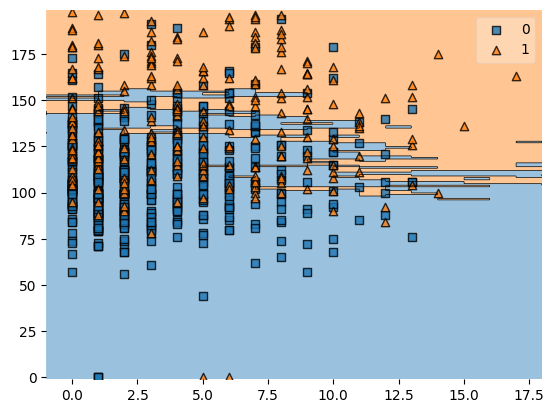

In [76]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=knn)
plt.show()

In [77]:
from sklearn.cluster import KMeans
WCSS=[]

In [78]:
for i in range(2,21):
    km=KMeans(n_clusters=i,init='k-means++')
    km.fit(X)
    WCSS.append(km.inertia_)


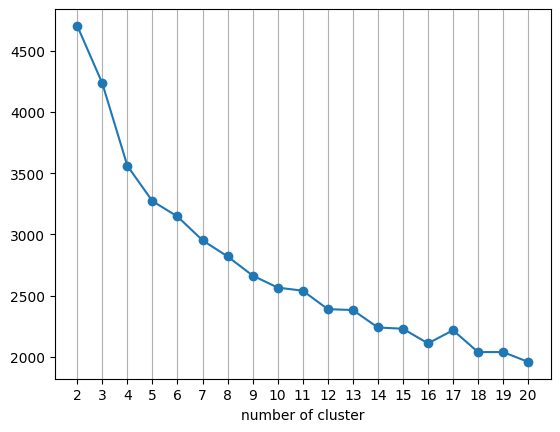

In [80]:
plt.plot([i for i in range(2,21)],WCSS,marker="o")
plt.xlabel("number of cluster")
plt.xticks([i for i in range(2,21)])
plt.grid(axis="x")
plt.show()

In [89]:
kmc=KMeans(n_clusters=3,init="k-means++")
X["pre"]=kmc.fit_predict(X)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
plt.plot(data=x,)